# Comparacion final entre metodos

Este notebook compara descenso por gradiente, algoritmo evolutivo, PSO y evolucion diferencial sobre dos casos de prueba del proyecto: Rosenbrock en 2D y Schwefel en 3D.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gradiente.funciones_gradientes import run_gradient_descent, rosenbrock_gradient, schwefel_gradient
from heuristicos.funciones_heuristicas import (
    run_differential_evolution,
    run_evolutionary_algorithm,
    run_particle_swarm_optimization,
)
from gradiente.funciones_objetivo import rosenbrock, schwefel

In [4]:
CASES = {
    "Rosenbrock 2D": {
        "objective_function": rosenbrock,
        "gradient_function": rosenbrock_gradient,
        "dimension": 2,
        "lower_bounds": -2.048,
        "upper_bounds": 2.048,
        "known_optimum": np.array([1.0, 1.0], dtype=float),
        "gradient_rate": 0.001,
        "gradient_iterations": 5000,
        "gradient_tolerance": 1e-8,
        "ea_population_size": 40,
        "ea_iterations": 120,
        "pso_swarm_size": 40,
        "pso_iterations": 120,
        "de_population_size": 40,
        "de_iterations": 120,
        "seed": 42,
    },
    "Schwefel 3D": {
        "objective_function": schwefel,
        "gradient_function": schwefel_gradient,
        "dimension": 3,
        "lower_bounds": -500.0,
        "upper_bounds": 500.0,
        "known_optimum": np.array([420.968746, 420.968746, 420.968746], dtype=float),
        "gradient_rate": 0.01,
        "gradient_iterations": 4000,
        "gradient_tolerance": 1e-8,
        "ea_population_size": 50,
        "ea_iterations": 150,
        "pso_swarm_size": 50,
        "pso_iterations": 150,
        "de_population_size": 50,
        "de_iterations": 150,
        "seed": 42,
    },
}

In [5]:
def random_initial_position(dimension: int, lower_bounds: float, upper_bounds: float, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return rng.uniform(lower_bounds, upper_bounds, size=dimension)


def summarize_result(case_name: str, method_name: str, result: dict, known_optimum: np.ndarray) -> dict:
    if "final_position" in result:
        best_solution = np.array(result["final_position"], dtype=float)
        best_value = float(result["final_value"])
        iterations = int(result["iterations"])
        evaluations = iterations + 1
    else:
        best_solution = np.array(result["best_solution"], dtype=float)
        best_value = float(result["best_value"])
        iterations = int(result["iterations"])
        evaluations = int(result["evaluations"])

    distance_to_optimum = float(np.linalg.norm(best_solution - known_optimum))

    return {
        "caso": case_name,
        "metodo": method_name,
        "mejor_valor": best_value,
        "iteraciones": iterations,
        "evaluaciones": evaluations,
        "distancia_al_optimo": distance_to_optimum,
        "mejor_solucion": np.array2string(best_solution, precision=4),
    }


def ejecutar_caso(case_name: str, config: dict) -> tuple[pd.DataFrame, dict]:
    objective_function = config["objective_function"]
    gradient_function = config["gradient_function"]
    dimension = config["dimension"]
    lower_bounds = config["lower_bounds"]
    upper_bounds = config["upper_bounds"]
    known_optimum = config["known_optimum"]
    seed = config["seed"]

    initial_position = random_initial_position(dimension, lower_bounds, upper_bounds, seed)

    gradient_result = run_gradient_descent(
        initial_position=initial_position,
        function=objective_function,
        gradient_function=gradient_function,
        rate=config["gradient_rate"],
        max_iterations=config["gradient_iterations"],
        tolerance=config["gradient_tolerance"],
    )

    evolutionary_result = run_evolutionary_algorithm(
        objective_function=objective_function,
        population_size=config["ea_population_size"],
        dimension=dimension,
        lower_bounds=lower_bounds,
        upper_bounds=upper_bounds,
        elitism_fraction=0.2,
        mutation_fraction=0.1,
        max_iterations=config["ea_iterations"],
        seed=seed,
    )

    pso_result = run_particle_swarm_optimization(
        objective_function=objective_function,
        swarm_size=config["pso_swarm_size"],
        dimension=dimension,
        lower_bounds=lower_bounds,
        upper_bounds=upper_bounds,
        inertia_weight=0.7,
        cognitive_weight=1.5,
        social_weight=1.5,
        max_iterations=config["pso_iterations"],
        seed=seed,
    )

    de_result = run_differential_evolution(
        objective_function=objective_function,
        population_size=config["de_population_size"],
        dimension=dimension,
        lower_bounds=lower_bounds,
        upper_bounds=upper_bounds,
        mutation_factor=0.8,
        crossover_rate=0.7,
        max_iterations=config["de_iterations"],
        seed=seed,
    )

    results = {
        "Descenso por gradiente": gradient_result,
        "Algoritmo evolutivo": evolutionary_result,
        "PSO": pso_result,
        "Evolucion diferencial": de_result,
    }

    summary_rows = [
        summarize_result(case_name, method_name, result, known_optimum)
        for method_name, result in results.items()
    ]

    summary_df = pd.DataFrame(summary_rows).sort_values(by=["mejor_valor", "distancia_al_optimo"])
    return summary_df, results

In [6]:
resumenes = []
resultados_por_caso = {}

for case_name, config in CASES.items():
    summary_df, results = ejecutar_caso(case_name, config)
    resumenes.append(summary_df)
    resultados_por_caso[case_name] = results

comparacion_df = pd.concat(resumenes, ignore_index=True)
comparacion_df

,caso,metodo,mejor_valor,iteraciones,evaluaciones,distancia_al_optimo,mejor_solucion
0,Rosenbrock 2D,Evolucion diferencial,5.245383e-15,120,4840,1.435695e-07,[1. 1.]
1,Rosenbrock 2D,PSO,7.632039e-09,120,4840,1.954682e-04,[0.9999 0.9998]
2,Rosenbrock 2D,Descenso por gradiente,1.513909e-03,5000,5001,8.572298e-02,[0.9611 0.9236]
3,Rosenbrock 2D,Algoritmo evolutivo,2.070444e-02,120,4840,2.800462e-01,[1.1223 1.2519]
4,Schwefel 3D,Evolucion diferencial,3.818301e-05,150,7550,4.917133e-05,[420.9687 420.9687 420.9688]
5,Schwefel 3D,Algoritmo evolutivo,8.749522e+00,150,7550,8.348696e+00,[418.7347 423.174 413.2327]
6,Schwefel 3D,PSO,1.184384e+02,150,7550,7.234937e+02,[-302.5249 420.9687 420.9687]
7,Schwefel 3D,Descenso por gradiente,6.120396e+02,4000,4001,4.968169e+02,[203.8189 -25.8791 420.9654]


In [7]:
for case_name in CASES:
    print(case_name)
    display(
        comparacion_df[comparacion_df["caso"] == case_name]
        .sort_values(by=["mejor_valor", "distancia_al_optimo"])
        .reset_index(drop=True)
    )


Rosenbrock 2D


,caso,metodo,mejor_valor,iteraciones,evaluaciones,distancia_al_optimo,mejor_solucion
0,Rosenbrock 2D,Evolucion diferencial,5.245383e-15,120,4840,1.435695e-07,[1. 1.]
1,Rosenbrock 2D,PSO,7.632039e-09,120,4840,1.954682e-04,[0.9999 0.9998]
2,Rosenbrock 2D,Descenso por gradiente,1.513909e-03,5000,5001,8.572298e-02,[0.9611 0.9236]
3,Rosenbrock 2D,Algoritmo evolutivo,2.070444e-02,120,4840,2.800462e-01,[1.1223 1.2519]


Schwefel 3D


,caso,metodo,mejor_valor,iteraciones,evaluaciones,distancia_al_optimo,mejor_solucion
0,Schwefel 3D,Evolucion diferencial,0.000038,150,7550,0.000049,[420.9687 420.9687 420.9688]
1,Schwefel 3D,Algoritmo evolutivo,8.749522,150,7550,8.348696,[418.7347 423.174 413.2327]
2,Schwefel 3D,PSO,118.438373,150,7550,723.493681,[-302.5249 420.9687 420.9687]
3,Schwefel 3D,Descenso por gradiente,612.039639,4000,4001,496.816909,[203.8189 -25.8791 420.9654]


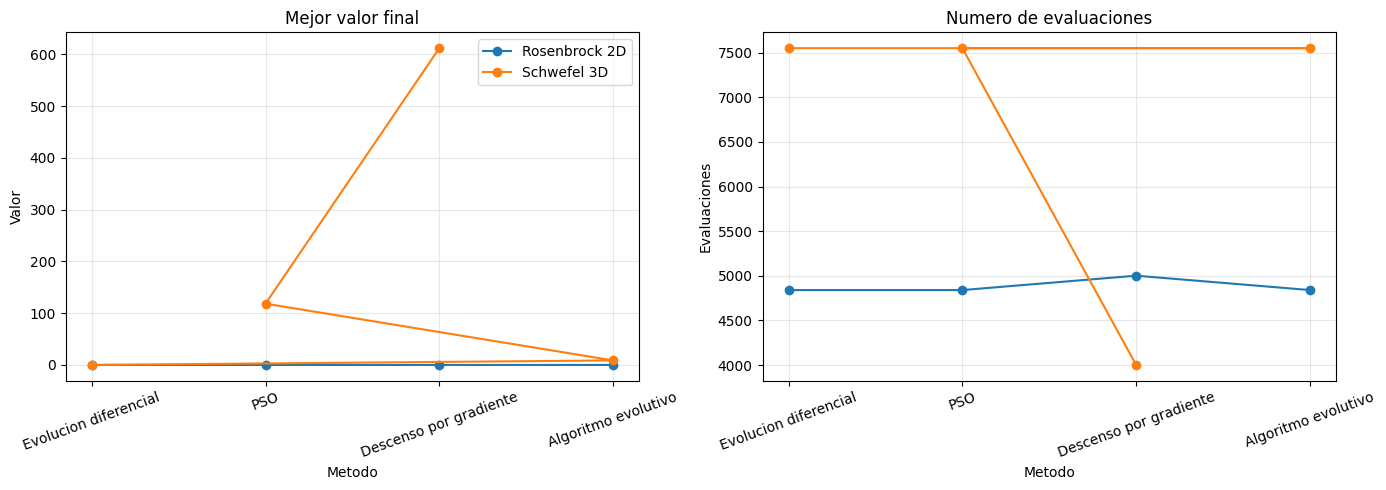

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(
    axes,
    ["mejor_valor", "evaluaciones"],
    ["Mejor valor final", "Numero de evaluaciones"],
):
    for case_name in CASES:
        data = comparacion_df[comparacion_df["caso"] == case_name]
        ax.plot(data["metodo"], data[metric], marker="o", label=case_name)
    ax.set_title(title)
    ax.set_xlabel("Metodo")
    ax.tick_params(axis="x", rotation=20)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Valor")
axes[1].set_ylabel("Evaluaciones")
axes[0].legend()
plt.tight_layout()
plt.show()

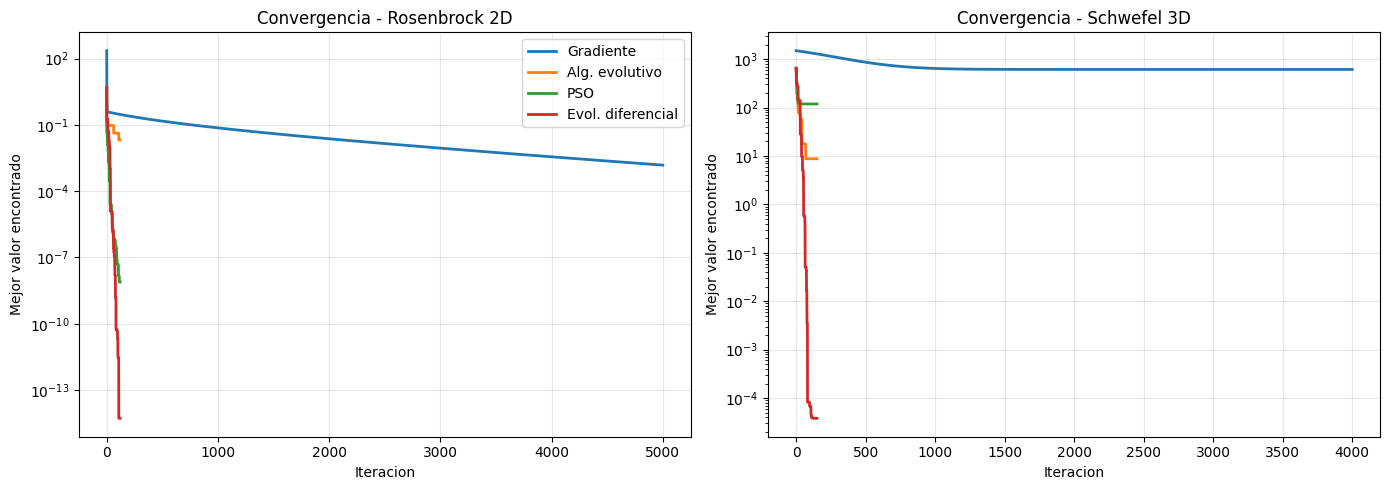

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, case_name in zip(axes, CASES):
    results = resultados_por_caso[case_name]

    ax.plot(results["Descenso por gradiente"]["function_values"], label="Gradiente", linewidth=2)
    ax.plot(results["Algoritmo evolutivo"]["best_values_history"], label="Alg. evolutivo", linewidth=2)
    ax.plot(results["PSO"]["best_values_history"], label="PSO", linewidth=2)
    ax.plot(results["Evolucion diferencial"]["best_values_history"], label="Evol. diferencial", linewidth=2)
    ax.set_title(f"Convergencia - {case_name}")
    ax.set_xlabel("Iteracion")
    ax.set_ylabel("Mejor valor encontrado")
    ax.set_yscale("log")
    ax.grid(alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()

In [10]:
ranking = (
    comparacion_df.copy()
    .sort_values(by=["caso", "mejor_valor", "distancia_al_optimo"])
    .groupby("caso")
    .head(1)
    [["caso", "metodo", "mejor_valor", "distancia_al_optimo"]]
    .reset_index(drop=True)
)

ranking

,caso,metodo,mejor_valor,distancia_al_optimo
0,Rosenbrock 2D,Evolucion diferencial,5.245383e-15,1.435695e-07
1,Schwefel 3D,Evolucion diferencial,3.818301e-05,4.917133e-05


## Lectura sugerida de resultados

- `mejor_valor`: que tan bien minimizo cada metodo.
- `evaluaciones`: cuantas evaluaciones de la funcion objetivo uso cada metodo.
- `distancia_al_optimo`: que tan cerca quedo de la solucion conocida.
- La curva de convergencia permite ver si el metodo mejora rapido, lento o si se estanca.